# Step 1 : Introduction to CNNs

## Imports

In [133]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix

## Tools / functions

In [117]:
def display_image(dataset, classes):
    plt.figure(figsize=(10, 10))
    i=0
    for images, labels in dataset.take(2):
        ax = plt.subplot(1, 2, i + 1)
        plt.imshow(images[0].numpy().astype("uint8"))
        plt.title(classes[labels[0]])
        plt.axis("off")
        i+=1

# Step 2: Dataset Exploration

In [ ]:
# Parameters
batch_size = 1 #Used in the for loops (the number of image given to each loop)
data_dir = 'cats_and_dogs_filtered'
validation_split=0.2

In [113]:
# load the dataset
train = tf.keras.utils.image_dataset_from_directory(
  data_dir+"/train",
  validation_split=validation_split,
  subset="training",
  seed=342,
  batch_size=batch_size,
  image_size=(256,256),
  interpolation="bilinear")

validation = tf.keras.utils.image_dataset_from_directory(
  data_dir+"/validation",
  seed=342,
  batch_size=batch_size,
  image_size=(256,256),
  interpolation="bilinear")

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 1000 files belonging to 2 classes.


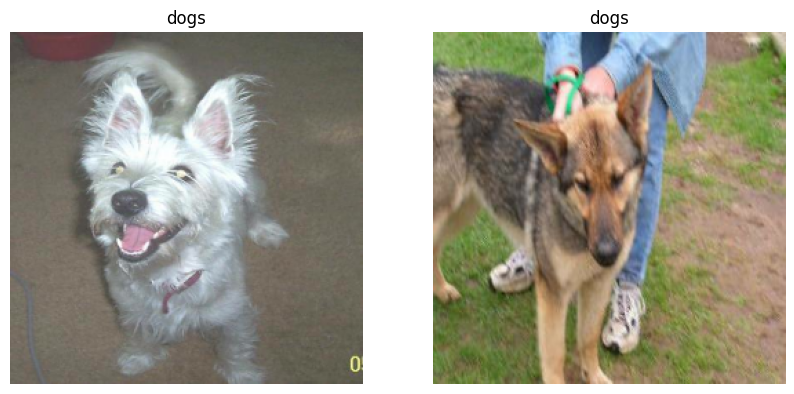

In [120]:
display_image(train,train.class_names)

# Step 3: Build Your CNN Model

In [ ]:
# Model Parameters

A lot of help was found from this [site](https://www.tensorflow.org/tutorials/load_data/images)

In [106]:

# Build the MLP
model = Sequential([
    #Scaling the RGB values to be from 0 to 1
    tf.keras.layers.Rescaling(1./255, name="Scaling_layer", input_shape=(256,256,3)),
    #First Convolution/Pooling layer
    tf.keras.layers.Conv2D(16,(3,3),strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_1"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_1",),

    #Second Convolution/Pooling layer
    tf.keras.layers.Conv2D(32,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_2"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_2",),

    #Third Convolution/Pooling layer
    tf.keras.layers.Conv2D(32,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_3"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_3",),

    #Fourth and final Convolution/Pooling layer
    tf.keras.layers.Conv2D(128,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_4"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_4",),

    # Finish
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),

    #Dense layer and output
    Dense(2, activation='relu',  name="output_layer"),
    tf.keras.layers.Softmax(name="output_function"),
])

# Compile the model
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate =0.1),
    # Loss function to minimize
    loss='SparseCategoricalCrossentropy',
    # List of metrics to monitor
    metrics=['accuracy']
)

# Display the architecture
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Scaling_layer (Rescaling)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution_1 (Conv2D)          │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing_1 (MaxPooling2D)     │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution_2 (Conv2D)          │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing_2 (MaxPooling2D)     │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution_3 (Conv2D)          │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing_3 (MaxPooling2D)     │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution_4 (Conv2D)          │ (None, 32, 32, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing_4 (MaxPooling2D)     │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_function (Softmax)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,148,674 (8.20 MB)

 Trainable params: 2,148,674 (8.20 MB)

 Non-trainable params: 0 (0.00 B)

# Step 4: Train the Model

In [107]:
model.fit(
    train,
    epochs=2,
)

Epoch 1/2
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.5019 - loss: 0.6932
Epoch 2/2
160/160 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.5031 - loss: 0.6931


# Step 5: Evaluate the Model on the test set

In [89]:
results = model.evaluate(validation)
print("test loss, test acc:", results)

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5000 - loss: 0.6931
test loss, test acc: [0.693146288394928, 0.5]


In [108]:
predictions = model.predict(validation)
print(predictions)

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step
[[0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 ...
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]]


In [ ]:
def to_labels(predictions):
    labels = [0 if pred.argmax() else 1 for pred in predictions]
    return labels

In [138]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

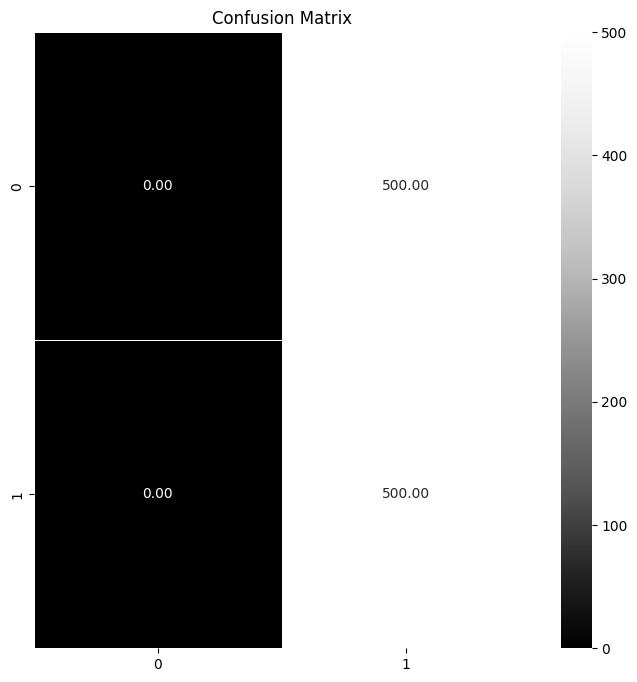

In [147]:
label = []
for images, labels in validation:
    label.append(labels[0])
confusionmatrix = confusion_matrix(label, to_labels(predictions))
plt.figure(figsize=(8,8))
sns.heatmap(confusionmatrix, annot=True, cmap="Greys_r", fmt=".2f", linewidths=0.5)
plt.title("Confusion Matrix")
plt.show()

# Step 6: Try to Improve the Model

# Bonus Challenge: Transfer Learning